*КЛАССИФИКАЦИЯ ЭЭГ-СИГНАЛОВ ВООБРАЖАЕМОГО ДВИЖЕНИЯ (ЛЕВАЯ vs ПРАВАЯ РУКА)*

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import pywt
import scipy.signal as signal

PATHS = {
    'train_data': "MI-EEG-B9T_train.csv",
    'train_label': "2class_MI_EEG_train_9.csv",
    'test_data': "MI-EEG-B9E_test.csv",
    'test_label': "2class_MI_EEG_test_9.csv"
}

print("Инициализация загрузки информации...")

x_train = pd.read_csv(PATHS['train_data'], header=None).values
y_train = pd.read_csv(PATHS['train_label'], header=None).values.ravel()
x_test = pd.read_csv(PATHS['test_data'], header=None).values
y_test = pd.read_csv(PATHS['test_label'], header=None).values.ravel()


print(f"Размерность тренировочного набора: {x_train.shape}, размерность целевых меток: {y_train.shape}")
print(f"Размерность тестового набора: {x_test.shape}, размерность целевых меток: {y_test.shape}")

#
print("\nБаланс классов в тренировочном наборе:")

class_names = [
    'Левая рука сжата в кулак (класс 0)',
    'Правая рука сжата в кулак (класс 1)'
]

unique, counts = np.unique(y_train, return_counts=True)
class_balance = dict(zip(class_names, counts))
print(class_balance)

Инициализация загрузки информации...
Размерность тренировочного набора: (400, 3000), размерность целевых меток: (400,)
Размерность тестового набора: (320, 3000), размерность целевых меток: (320,)

Баланс классов в тренировочном наборе:
{'Левая рука сжата в кулак (класс 0)': 200, 'Правая рука сжата в кулак (класс 1)': 200}


*Подготовка данных и 1D-CNN*

Сигналы ЭЭГ очищаются полосовым фильтром Баттерворта, выделяющим диапазон, связанный с мысленным движением, а затем нормализуются. После этого обучается одномерная свёрточная нейросеть, специально спроектированная для анализа временных рядов. Для борьбы с переобучением и неравномерным распределением классов используются Dropout, L2-регуляризация и балансировка весов.

In [67]:
print("\nФильтрация и стандартизация сигналов...")
def butter_band(data, low=8, high=30, fs=250):
    nyq = 0.5 * fs
    b,a = signal.butter(4, [low/nyq, high/nyq], 'band')
    return signal.filtfilt(b,a,data,axis=1)

x_train_filt = butter_band(x_train)
x_test_filt = butter_band(x_test)

scaler = StandardScaler()
x_train_norm = scaler.fit_transform(x_train_filt)
x_test_norm = scaler.transform(x_test_filt)

X_train = x_train_norm.reshape(-1,3000,1)
X_test = x_test_norm.reshape(-1,3000,1)
Y_train = tf.keras.utils.to_categorical(y_train, 2)
Y_test = tf.keras.utils.to_categorical(y_test, 2)

print("\nПостроение 1D-CNN модели...")
model = Sequential([
    Conv1D(16, 15, activation='relu', input_shape=(3000,1)),
    MaxPooling1D(3),
    Dropout(0.2),

    Conv1D(32, 10, activation='relu'),
    MaxPooling1D(3),
    Dropout(0.2),

    Conv1D(64, 5, activation='relu'),
    MaxPooling1D(3),
    Dropout(0.2),

    Flatten(),
    Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0005)),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

model.compile(optimizer=Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print("Веса классов:", class_weight_dict)

early = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)

print("\nНачало обучения...")
history = model.fit(
    X_train, Y_train,
    batch_size=16,
    epochs=20,
    validation_data=(X_test, Y_test),
    callbacks=[early],
    shuffle=True,
    class_weight=class_weight_dict
)


Фильтрация и стандартизация сигналов...

Построение 1D-CNN модели...
Веса классов: {0: 1.0, 1: 1.0}

Начало обучения...
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5200 - loss: 0.8475 - val_accuracy: 0.5125 - val_loss: 0.7444
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4900 - loss: 0.7481 - val_accuracy: 0.5531 - val_loss: 0.7382
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5275 - loss: 0.7376 - val_accuracy: 0.6906 - val_loss: 0.7331
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5675 - loss: 0.7326 - val_accuracy: 0.6625 - val_loss: 0.7287
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5400 - loss: 0.7279 - val_accuracy: 0.5750 - val_loss: 0.7227
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6000 - loss: 0.7195 - val_accuracy: 0.7469 - val_loss: 0.7161
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6550 - loss: 0.7027 - val_accuracy: 0.5625 - val_los

*Проверка качества модели*

Модель оценивается на тестовых данных: строится матрица ошибок с точностью классификации, а также кривые обучения (потери и точность на тренировке и валидации). Такой анализ помогает понять, насколько модель способна обобщать информацию, избегать переобучения и эффективно распознавать двигательные образы по ЭЭГ.

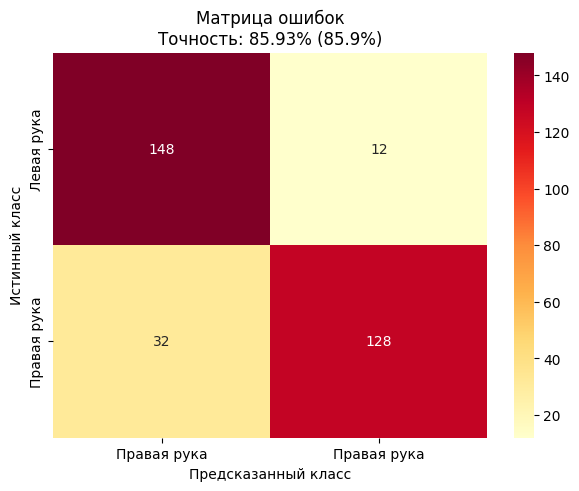

Точность: 85.93% (85.9%)


In [ ]:
y_pred = model.predict(X_test, verbose=0)
y_pred_cls = np.argmax(y_pred, axis=1)
acc = accuracy_score(y_test, y_pred_cls)

# Матрица ошибок с точностью на графике
cm = confusion_matrix(y_test, y_pred_cls)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Левая кулак','Правая кулак'], 
            yticklabels=['Левая кулак','Правая кулак'])
plt.title(f"Матрица ошибок\nТочность: {acc:.4f} ({acc*100:.2f}%)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()